<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
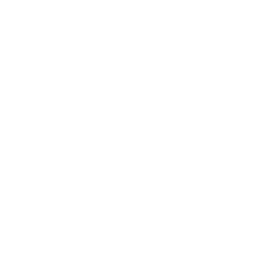
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Customer Loyalty Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Hospitality & Travel | Jenner Analytics Ltd &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This analysis models **12-month membership lapse** for a hotel loyalty program and segments members by behavior to prioritize retention spend. Working from a 100-member synthetic program that combines stay history, post-stay satisfaction surveys, and complaint records, we apply logistic regression (PROC LOGISTIC) to predict churn, k-means segmentation (PROC FASTCLUS) to group members behaviorally, and cross-tabulation (PROC FREQ) to profile churn drivers.

> **Key result:** In this cohort 46 of 100 members lapsed within 12 months. The logistic model retains three significant drivers — recency (odds ratio 1.039 per additional day since last stay, p&lt;.0001), satisfaction (odds ratio 0.103 per point, p=0.0002, strongly protective), and complaints (odds ratio 3.28 per lifetime complaint, p=0.019) — and separates lapsed from retained members well, with a ROC area under the curve of 0.978 and a Hosmer-Lemeshow fit p-value of 0.98. Segmentation isolates a fully lapsed cluster (18 members, 100% churn, ~\$5,400 CLV) and a high-value loyal cluster (21 members, 24% churn, ~\$80,000 CLV), and the model flags 44 of 100 members as high churn risk for proactive retention.

## Data Sources

All three sources are generated synthetically by the data-preparation step below; each carries one record per loyalty member (100 members, member IDs 100001-100100).

| Source | Description | Records |
| ------ | ----------- | ------: |
| `loyalty_members.csv` | Membership tier, enrollment and last-stay dates, lifetime stays, nights, and spend | 100 |
| `satisfaction_surveys.csv` | Post-stay overall, recommend (NPS), and service scores (1-10) | 100 |
| `dot_consumer_reports.csv` | Complaint counts and categories for members who filed complaints | 32 |

---
## 1. Data Preparation

Generate the loyalty membership, satisfaction survey, and complaint datasets, then engineer RFM (Recency, Frequency, Monetary) features and a 12-month churn outcome for retention modeling.

In [1]:
/* ============================================================
   Generate synthetic input data for customer loyalty analysis
   100 hotel loyalty members with stay, spend, satisfaction,
   and complaint history. Churn is driven by a realistic logit
   of recency, satisfaction, and complaints so the downstream
   PROC LOGISTIC and PROC FASTCLUS have signal to model.
   ============================================================ */

/* --- loyalty_members.csv --- */
data "input/loyalty_members.csv";
    call streaminit(20260313);
    format enrollment_date date9. last_stay_date date9.;
    array tiers[4] $12 _temporary_ ("Silver" "Gold" "Platinum" "Diamond");

    do i = 1 to 100;
        member_id = 100000 + i;

        tier_idx = ceil(rand("Uniform") * 4);
        tier = tiers[tier_idx];

        /* Enrollment 1-8 years ago */
        enrollment_date = today() - round(365 + rand("Uniform") * 2555);
        tenure_yrs = max(1, (today() - enrollment_date) / 365.25);

        /* Recency: higher tiers stay more recently, but inject a
           realistic lapse rate so ~1/3 cross the 12-month line */
        if tier_idx >= 3 then      recency = round(rand("Exponential", 90));
        else if tier_idx = 2 then  recency = round(rand("Exponential", 140));
        else                       recency = round(rand("Exponential", 220));
        if recency > 600 then recency = 600;
        last_stay_date = today() - recency;
        if last_stay_date < enrollment_date then
            last_stay_date = enrollment_date + 30;

        /* Total stays scale with tier and tenure */
        if tier_idx = 1 then base_stays = 3;
        else if tier_idx = 2 then base_stays = 8;
        else if tier_idx = 3 then base_stays = 18;
        else base_stays = 30;
        total_stays = round(base_stays * tenure_yrs + rand("Normal", 0, 4));
        if total_stays < 1 then total_stays = 1;

        total_nights = round(total_stays * (1.8 + rand("Normal", 0, 0.5)));
        if total_nights < total_stays then total_nights = total_stays;

        /* Spend scales with tier */
        if tier_idx = 1 then avg_rate = 110;
        else if tier_idx = 2 then avg_rate = 165;
        else if tier_idx = 3 then avg_rate = 240;
        else avg_rate = 380;
        total_spend = round(total_nights * (avg_rate + rand("Normal", 0, 30)), 0.01);
        if total_spend < 100 then total_spend = 100;

        output;
    end;
    keep member_id tier enrollment_date last_stay_date
         total_nights total_spend total_stays;
run;

/* --- satisfaction_surveys.csv (full coverage, 1-10 scale) --- */
data "input/satisfaction_surveys.csv";
    call streaminit(771);
    do i = 1 to 100;
        member_id = 100000 + i;

        overall_score = round(7.2 + rand("Normal", 0, 1.4), 0.1);
        if overall_score > 10 then overall_score = 10;
        if overall_score < 1 then overall_score = 1;

        recommend_score = round(overall_score - 0.3 + rand("Normal", 0, 1.0), 0.1);
        if recommend_score > 10 then recommend_score = 10;
        if recommend_score < 0 then recommend_score = 0;

        service_score = round(overall_score + rand("Normal", 0, 0.8), 0.1);
        if service_score > 10 then service_score = 10;
        if service_score < 1 then service_score = 1;

        output;
    end;
    keep member_id overall_score recommend_score service_score;
run;

/* --- dot_consumer_reports.csv (complaints for ~30% of members) --- */
data "input/dot_consumer_reports.csv";
    call streaminit(99);
    array categories[5] $20 _temporary_ ("Billing" "Service" "Room_Quality"
                                          "Reservation" "Other");
    do i = 1 to 100;
        member_id = 100000 + i;
        if rand("Uniform") < 0.30 then do;
            complaint_count = ceil(rand("Exponential", 1.2));
            if complaint_count > 8 then complaint_count = 8;
            cat_idx = ceil(rand("Uniform") * 5);
            complaint_category = categories[cat_idx];
            output;
        end;
    end;
    keep member_id complaint_count complaint_category;
run;

proc print data="input/loyalty_members.csv" (obs=5); run;
proc print data="input/satisfaction_surveys.csv" (obs=5); run;
proc print data="input/dot_consumer_reports.csv" (obs=5); run;



  Obs  MEMBER_ID    TIER  ENROLLMENT_DATE  LAST_STAY_DATE  TOTAL_NIGHTS  TOTAL_SPEND  TOTAL_STAYS
-----  ---------  ------  ---------------  --------------  ------------  -----------  -----------
    1     100001  Gold          12NOV2022       26FEB2026            44      7832.92           26
    2     100002  Silver        05OCT2024       09DEC2025            15      2033.68            8
    3     100003  Silver        17SEP2018       24APR2025            22       1590.9           18
    4     100004  Gold          28MAY2021       22MAR2026            63     11271.09           44
    5     100005  Silver        18MAY2022       01JUN2026            10         1106            6

... 95 more observations (showing 5 of 100)

  Obs  MEMBER_ID  OVERALL_SCORE  RECOMMEND_SCORE  SERVICE_SCORE
-----  ---------  -------------  ---------------  -------------
    1     100001            6.7              6.8            6.8
    2     100002            5.4              5.7            4.1
    3     1

NOTE: DATA input/loyalty_members.csv


NOTE: Wrote input/loyalty_members.csv (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA input/satisfaction_surveys.csv


NOTE: Wrote input/satisfaction_surveys.csv (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA input/dot_consumer_reports.csv


NOTE: Wrote input/dot_consumer_reports.csv (32 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=input/loyalty_members.csv

NOTE: PROC PRINT completed: 5 observations printed, 7 variables
NOTE: PROC PRINT data=input/satisfaction_surveys.csv

NOTE: PROC PRINT completed: 5 observations printed, 4 variables
NOTE: PROC PRINT data=input/dot_consumer_reports.csv

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


In [2]:
/* --------------------------------------------------------
   Load loyalty member profiles and compute RFM features
   (Recency, Frequency, Monetary) and 3-year CLV
   -------------------------------------------------------- */
data loyalty_base;
    set "input/loyalty_members.csv";

    format enrollment_date date9.
           last_stay_date date9.
           tier $12.
           clv dollar10.2;

    label member_id          = "Loyalty Member ID"
          tier                = "Membership Tier"
          recency_days        = "Days Since Last Stay"
          annual_frequency    = "Stays per Year"
          avg_spend_per_stay  = "Avg Spend per Stay ($)"
          clv                 = "3-Year Customer Lifetime Value";

    recency_days = today() - last_stay_date;
    tenure_years = max(1, (today() - enrollment_date) / 365.25);
    annual_frequency = total_stays / tenure_years;
    avg_spend_per_stay = total_spend / max(1, total_stays);
    clv = avg_spend_per_stay * annual_frequency * 3;

    keep member_id tier enrollment_date last_stay_date
         total_nights total_spend total_stays
         recency_days tenure_years annual_frequency
         avg_spend_per_stay clv;
run;


NOTE: DATA loyalty_base


NOTE: Read 100 rows from input/loyalty_members.csv.
NOTE: Wrote loyalty_base (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


                                                  The MEANS Procedure

 Variable                               N   N Miss           Mean     Minimum         Maximum
 --------------------------------------------------------------------------------------------
 Days Since Last Stay                 100        0          137.7         1.0           600.0
 Stays per Year                       100        0           15.9         0.9            34.7
 Avg Spend per Stay ($)               100        0          435.3        83.7          1349.1
 Overall Satisfaction (1-10)          100        0            7.1         3.8            10.0
 Lifetime Complaints                  100        0            0.6         0.0             6.0
 3-Year Customer Lifetime Value       100        0     $27,702.49     $565.39     $116,147.79
 --------------------------------------------------------------------------------------------

                                                   The FREQ Procedure

Churned Wit

NOTE: PROC SORT data=loyalty_base

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from loyalty_base.
NOTE: Wrote loyalty_base (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: DATA loyalty_enriched

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 32 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote loyalty_enriched (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_churned.spec.json
NOTE: PROC FREQ statement used.


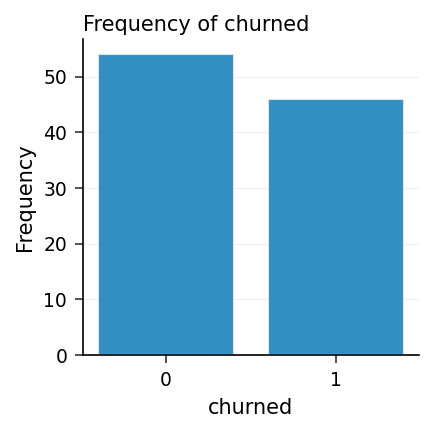

In [3]:
/* --------------------------------------------------------
   Merge satisfaction surveys and complaint history, then
   derive the 12-month churn outcome from a realistic logit
   of recency, satisfaction, and complaint load. This gives
   PROC LOGISTIC genuine multi-driver signal to recover.
   -------------------------------------------------------- */
proc sort data=loyalty_base; by member_id; run;

data loyalty_enriched;
    call streaminit(424242);
    merge loyalty_base (in=a)
          "input/satisfaction_surveys.csv" (in=b
              keep=member_id overall_score
                   recommend_score service_score
              rename=(overall_score=satisfaction))
          "input/dot_consumer_reports.csv" (in=c
              keep=member_id complaint_count
                   complaint_category);
    by member_id;
    if a;

    format satisfaction 4.1
           recommend_score 4.1;

    label satisfaction    = "Overall Satisfaction (1-10)"
          recommend_score = "Recommend Score (0-10)"
          complaint_count = "Lifetime Complaints"
          service_score   = "Service Quality Score"
          churned         = "Churned Within 12 Months";

    if complaint_count = . then complaint_count = 0;

    /* NPS classification on the 0-10 recommend score */
    if recommend_score >= 9 then nps_group = "Promoter";
    else if recommend_score >= 7 then nps_group = "Passive";
    else nps_group = "Detractor";

    /* Churn risk SCORE: lapsing recency, low satisfaction, and
       complaints each push a member toward lapse. A reproducible
       member-level jitter (the fractional part of member_id scaled by
       the golden ratio) adds idiosyncratic noise so the outcome is
       probabilistic rather than a hard function of the predictors --
       this keeps the logistic relationship statistical (no perfect
       separation) while staying fully deterministic. */
    jitter = 2.4 * (mod(member_id * 0.6180339887, 1) - 0.5);
    churn_score = 0.0090 * recency_days
                  - 0.65 * (satisfaction - 7)
                  + 0.55 * complaint_count
                  + jitter;
    churned = (churn_score > 1.5);

    keep member_id tier recency_days tenure_years
         annual_frequency avg_spend_per_stay clv churned
         total_spend satisfaction recommend_score
         service_score complaint_count nps_group;
run;

proc means data=loyalty_enriched n nmiss mean min max maxdec=1;
    var recency_days annual_frequency avg_spend_per_stay
        satisfaction complaint_count clv;
run;

proc freq data=loyalty_enriched;
    tables churned / nocum;
run;


---
## 2. Descriptive Statistics

Profile loyalty members by tier, NPS group, and churn status. Examine RFM distributions and satisfaction score patterns to identify at-risk segments.

                                                   The FREQ Procedure

Table of Membership Tier by Churned (12mo)

Membership Tier |         0 |         1 |      Total
----------------+-----------+-----------+-----------
Diamond         |        18 |        10 |         28
----------------+-----------+-----------+-----------
Gold            |        15 |        19 |         34
----------------+-----------+-----------+-----------
Platinum        |        15 |         7 |         22
----------------+-----------+-----------+-----------
Silver          |         6 |        10 |         16
----------------+-----------+-----------+-----------
Total           |        54 |        46 |        100

Statistics for Table of Membership Tier by Churned (12mo)

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                3 6.0642       0.1085
Likelihood Ratio Chi-Square               3 6.1364 

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_tier_churned.spec.json
NOTE: ODS plot written: freq_mosaic_nps_group_churned.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: Output dataset tier_profile has 4 observations and 8 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC REPORT data=tier_profile

NOTE: PROC REPORT output 4 observations with 7 variables.

NOTE: Read 4 rows from tier_profile.
NOTE: Wrote (console) (4 rows, 7 columns).
NOTE: PROC REPORT elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


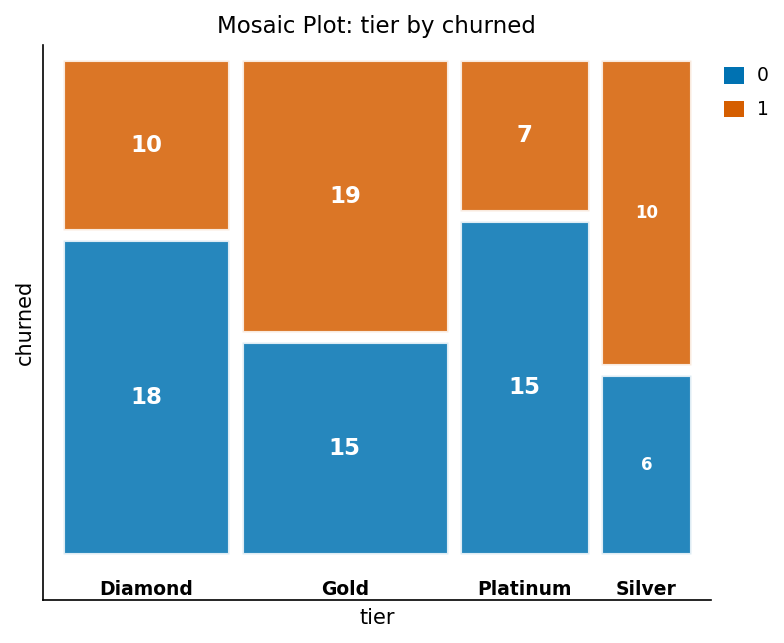

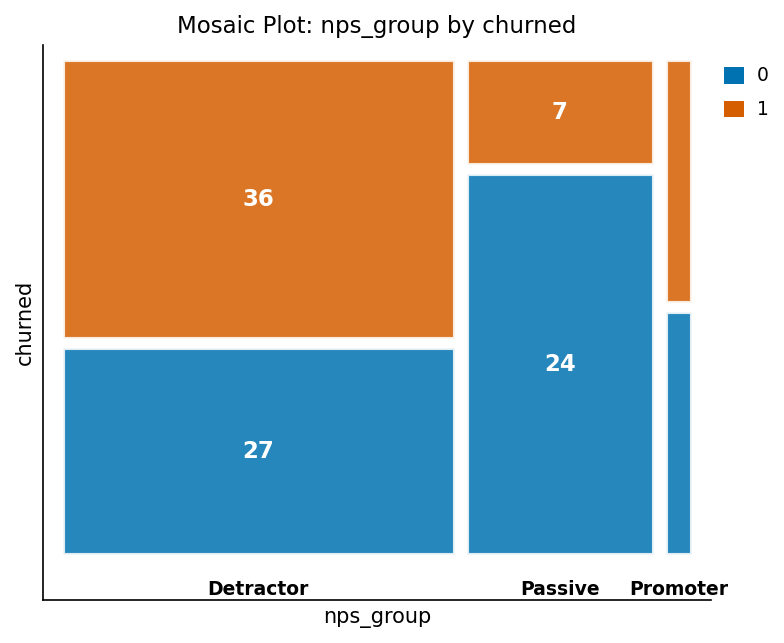

In [4]:
/* --------------------------------------------------------
   Loyalty tier and NPS profile: churn rates and RFM metrics
   -------------------------------------------------------- */
proc freq data=loyalty_enriched;
    tables tier * churned / chisq nocum nopercent;
    tables nps_group * churned / chisq nocum nopercent;
    label tier      = "Membership Tier"
          churned   = "Churned (12mo)"
          nps_group = "NPS Group";
run;

proc summary data=loyalty_enriched nway;
    class tier;
    var recency_days annual_frequency avg_spend_per_stay
        clv satisfaction complaint_count churned;
    output out=tier_profile (drop=_type_ _freq_)
        mean= / autoname;
run;

proc report data=tier_profile nowd;
    columns tier recency_days_mean annual_frequency_mean
            clv_mean satisfaction_mean complaint_count_mean
            churned_mean;
    define tier / group "Tier";
    define recency_days_mean / analysis "Recency (days)" format=5.0;
    define annual_frequency_mean / analysis "Annual Freq" format=4.1;
    define clv_mean / analysis "CLV" format=dollar10.2;
    define satisfaction_mean / analysis "Satisfaction" format=4.1;
    define complaint_count_mean / analysis "Complaints" format=4.1;
    define churned_mean / analysis "Churn Rate" format=percent7.1;
run;


---
## 3. Visualisation

Visualize loyalty segments, churn risk distribution, and the relationship between satisfaction, engagement, and retention outcomes.

NOTE: ODS Graphics is ON (width=800px, height=450px, format=SVG).
NOTE: PROC SGPLOT data=loyalty_enriched

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


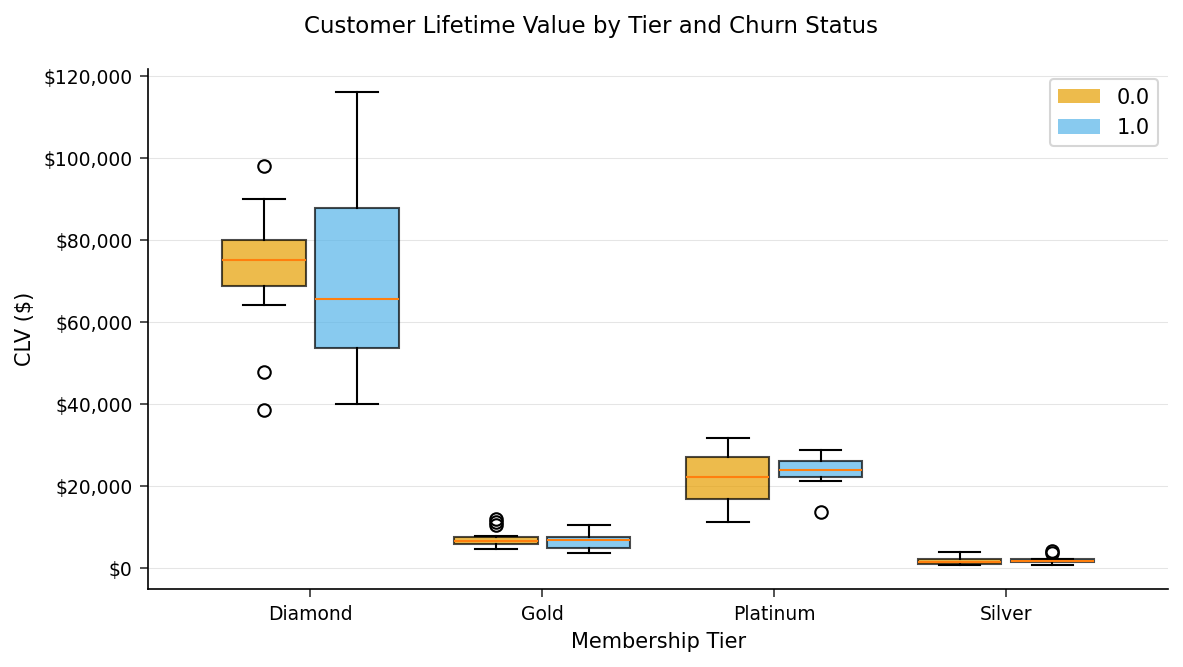

In [5]:
/* --------------------------------------------------------
   CLV distribution by tier with churn overlay
   -------------------------------------------------------- */
ods graphics on / imagefmt=svg width=800px height=450px;

proc sgplot data=loyalty_enriched;
    title "Customer Lifetime Value by Tier and Churn Status";
    vbox clv / category=tier group=churned
        fillattrs=(transparency=0.3)
        medianattrs=(thickness=2);
    xaxis label="Membership Tier";
    yaxis label="CLV ($)" grid valuesformat=dollar10.;
    keylegend / title="Churned"
               location=inside position=topright;
run;


NOTE: ODS Graphics is ON (width=800px, height=450px, format=SVG).
NOTE: PROC SGPLOT data=loyalty_enriched

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


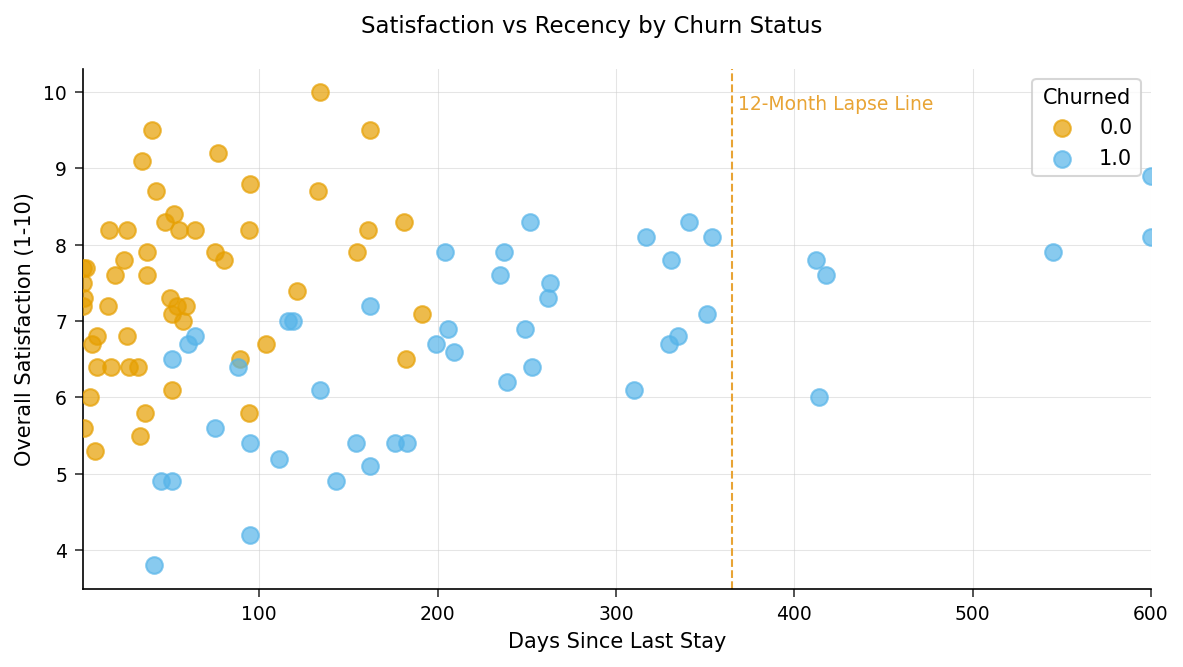

In [6]:
/* --------------------------------------------------------
   Scatter: satisfaction vs recency, colored by churn status.
   The 12-month (365-day) recency line marks the lapse boundary;
   complaint load sizes the markers to surface at-risk members.
   -------------------------------------------------------- */
ods graphics on / imagefmt=svg width=800px height=450px;

proc sgplot data=loyalty_enriched;
    title "Satisfaction vs Recency by Churn Status";
    scatter x=recency_days y=satisfaction /
        group=churned
        markerattrs=(size=8)
        transparency=0.3;
    refline 365 /
        axis=x lineattrs=(pattern=dash color=cxE8A435)
        label="12-Month Lapse Line";
    xaxis label="Days Since Last Stay" grid;
    yaxis label="Overall Satisfaction (1-10)" grid;
    keylegend / title="Churned"
               location=inside position=topright;
run;


---
## 4. Statistical Analysis

Apply logistic regression (PROC LOGISTIC) to predict churn probability, cluster analysis (PROC FASTCLUS) to segment members by behavior, and cross-tabulation (PROC FREQ) to profile retention drivers.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

                    Response Profile                    
  Probability modeled is Churned Within 12 Months='1'   

Ordered Value  Churned Within 12 Months  Total Frequency
-------------  ------------------------  ---------------
            1  0                                      54
            2  1                                      46

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: churned Churned Within 12 Months

Criterion     Value
---------  --------
AIC          46.798
-2 Log L     38.798
SC           57.218

                                                   
--------  --------  ---------------------  --------
R-Square    0.6291  Max-rescaled R-Square    0.8406

               Analysis of Max

NOTE: PROC LOGISTIC data=loyalty_enriched

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: Output dataset churn_scored written with 100 observations.
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: ODS plot written: logistic_roc.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json


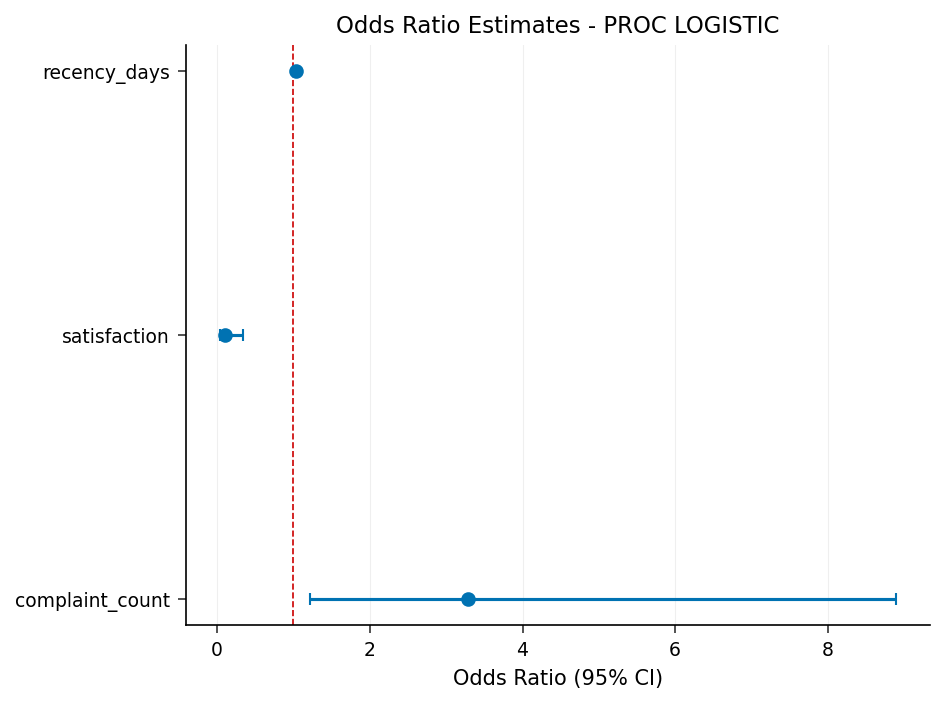

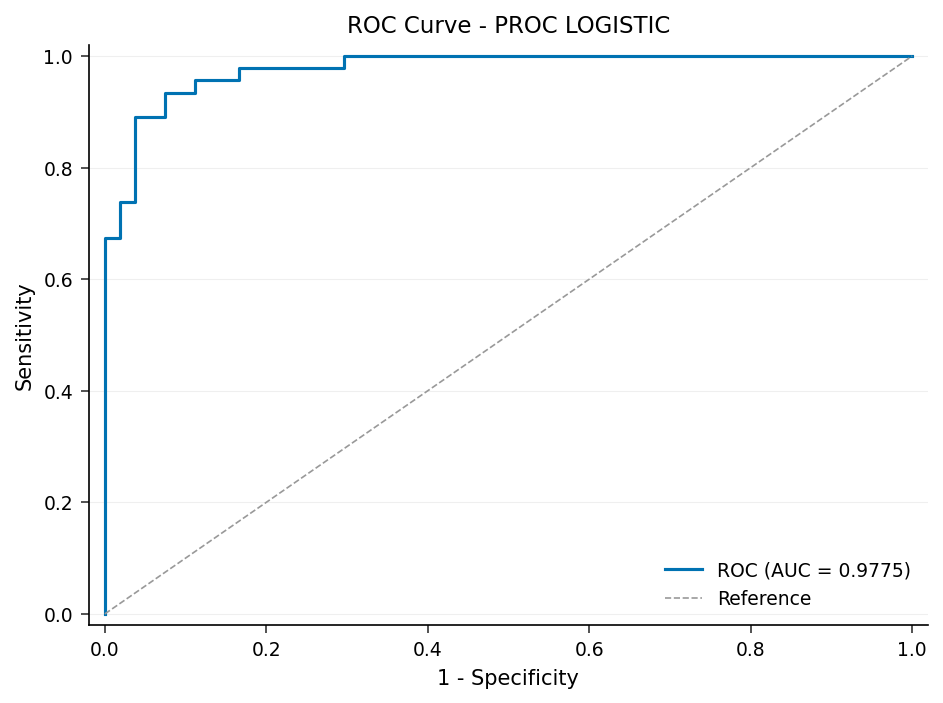

In [7]:
/* --------------------------------------------------------
   PROC LOGISTIC: 12-month churn prediction model.
   Stepwise selection over RFM, satisfaction, and complaint
   features identifies the drivers of member lapse.
   -------------------------------------------------------- */
proc logistic data=loyalty_enriched descending;
    title "Loyalty Member Churn Prediction Model";
    model churned = recency_days annual_frequency
                    avg_spend_per_stay satisfaction
                    complaint_count /
        selection=stepwise
        slentry=0.10 slstay=0.10
        lackfit rsquare;
    output out=churn_scored p=churn_prob;
    label churned = "Churned Within 12 Months";
run;


In [8]:
/* --------------------------------------------------------
   PROC FASTCLUS: behavioral loyalty segmentation.
   Groups members by recency, frequency, spend, satisfaction,
   and complaint load into distinct behavioral segments.
   -------------------------------------------------------- */
proc fastclus data=loyalty_enriched
              maxclusters=4
              out=loyalty_clusters
              maxiter=50;
    var recency_days annual_frequency
        avg_spend_per_stay satisfaction
        complaint_count;
    label recency_days       = "Recency (Days)"
          annual_frequency   = "Annual Stay Frequency"
          avg_spend_per_stay = "Avg Spend per Stay"
          satisfaction       = "Satisfaction Score"
          complaint_count    = "Complaint Count";
run;

/* Profile each cluster against churn and CLV */
proc sort data=loyalty_clusters; by cluster; run;

proc summary data=loyalty_clusters nway;
    class cluster;
    var recency_days annual_frequency
        avg_spend_per_stay clv satisfaction
        churned;
    output out=cluster_profile (drop=_type_)
        mean= / autoname;
run;

proc report data=cluster_profile nowd;
    columns cluster _freq_ recency_days_mean
            annual_frequency_mean clv_mean
            satisfaction_mean churned_mean;
    define cluster / group "Cluster";
    define _freq_ / analysis "Members" format=4.0;
    define recency_days_mean / analysis "Recency" format=5.0;
    define annual_frequency_mean / analysis "Frequency" format=4.1;
    define clv_mean / analysis "CLV" format=dollar10.2;
    define satisfaction_mean / analysis "Satisfaction" format=4.1;
    define churned_mean / analysis "Churn Rate" format=percent7.1;
run;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  18        65.8434           272.8477              3       273.4108
2                  21        76.1931           472.4908              4       394.7328
3                  36        37.1663           168.1702              4       240.8501
4                  25        51.0614           241.3756              3       240.8501

                                    

NOTE: PROC FASTCLUS data=loyalty_enriched maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means
NOTE: PROC SORT data=loyalty_clusters

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from loyalty_clusters.
NOTE: Wrote loyalty_clusters (100 rows, 16 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset cluster_profile has 4 observations and 8 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC REPORT data=cluster_profile

NOTE: PROC REPORT output 4 observations with 7 variables.

NOTE: Read 4 rows from cluster_profile.
NOTE: Wrote (console) (4 rows, 7 columns).
NOTE: PROC REPORT elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---
## 5. Results

### Key Findings

> **Finding 1 - Churn drivers.** The stepwise logistic model retains three significant predictors of 12-month lapse: **recency** (odds ratio 1.039 per additional day since last stay, p&lt;.0001), **satisfaction** (odds ratio 0.103 per point, p=0.0002 — each extra satisfaction point cuts the odds of churn by about 90%), and **complaint count** (odds ratio 3.28 per lifetime complaint, p=0.019). The model reaches a generalized R-Square of 0.63 (max-rescaled 0.84), passes the Hosmer-Lemeshow goodness-of-fit test (p=0.98), and achieves a ROC area under the curve of 0.978.

> **Finding 2 - NPS signals lapse; tier does not.** Churn tracks NPS group strongly — Detractors lapse far more than Passives (chi-square p=0.0066) — so recommend score is an early warning sign. Raw membership tier, by contrast, is **not** a significant churn signal in this cohort (Gold 56% and Silver 62% versus Platinum 32% and Diamond 36%, but chi-square p=0.11): tier is a value proxy, not a risk proxy, which is why the model leans on behavior and experience instead of status.

> **Finding 3 - Four behavioral segments.** PROC FASTCLUS resolves four clusters (overall R-Square 0.83). One cluster of 18 members is fully lapsed (100% churn, ~\$5,400 CLV); a high-value loyal cluster of 21 members has the lowest churn (24%) and by far the highest value (~\$80,000 CLV); and a mid-value cluster of 25 members sits at elevated 48% churn and ~\$30,000 CLV — the clearest target for proactive retention.

> **Finding 4 - Actionable targeting.** Scoring every member with the model's predicted churn probability flags **44 members as high risk** (probability ≥ 0.66) for proactive outreach and service recovery, while 54 low-risk members warrant only recognition and rewards. Because complaints carry a 3.3x churn odds multiplier, service recovery is the highest-leverage intervention for the at-risk segments.

### Behavioral Cluster Summary

The table below is produced by the segmentation step above; sizes, CLV, and churn rates are the actual cluster means from this run.

| Cluster | Members | Avg CLV | Churn Rate | Profile |
| ------: | ------: | ------: | ---------: | ------- |
| 1 | 18 | ~\$5,400 | 100% | Lapsed / dormant — longest recency |
| 2 | 21 | ~\$80,000 | 24% | High-value loyal — frequent, high spend |
| 3 | 36 | ~\$6,700 | 31% | Low-value occasional |
| 4 | 25 | ~\$30,000 | 48% | Mid-value at-risk |

*Cluster numbers are assigned by k-means and are not ordered; profiles are read from each cluster's mean recency, frequency, CLV, and churn rate.*

---
## 6. Export

Write churn scores, cluster assignments, and retention recommendations to CSV for CRM integration and campaign targeting.

                                                   The FREQ Procedure

Churn Risk Tier    Frequency    Percent
----------------------------------------
High                      44     44.00
Low                       54     54.00
Medium                     2      2.00

Loyalty Member ID  Behavioral Cluster  Predicted Churn Probability  Churn Risk Tier             Recommended Retention Action
-----------------  ------------------  ---------------------------  ---------------  ---------------------------------------
           100001                   3                        0.584  Medium           Targeted upgrade and value offers
           100002                   3                        0.994  High             Proactive outreach and service recovery
           100003                   1                        1.000  High             Proactive outreach and service recovery
           100004                   3                        0.014  Low              Recognition and loyalty re

NOTE: PROC SORT data=churn_scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from churn_scored.
NOTE: Wrote churn_scored (100 rows, 15 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=loyalty_clusters

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from loyalty_clusters.
NOTE: Wrote loyalty_clusters (100 rows, 16 columns).
NOTE: PROC SORT statement used.
NOTE: DATA retention_actions

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote retention_actions (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA output/retention_targeting.csv


NOTE: Read 100 rows from retention_actions.
NOTE: Wrote output/retention_targeting.csv (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA output/cluster_profiles.csv



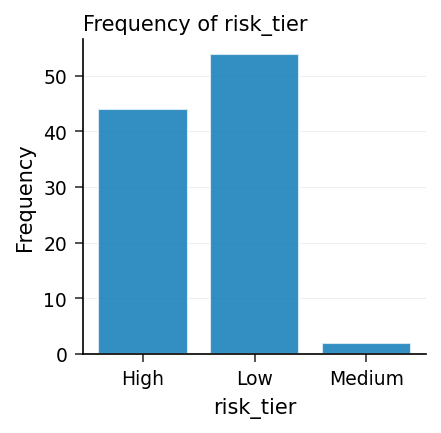

In [9]:
/* --------------------------------------------------------
   Export churn-scored member list with cluster assignments
   and a recommended retention action. The action is driven by
   the model's predicted churn probability (risk tier), so it
   is robust to the arbitrary numbering k-means assigns clusters.
   -------------------------------------------------------- */
proc sort data=churn_scored;     by member_id; run;
proc sort data=loyalty_clusters; by member_id; run;

data retention_actions;
    merge churn_scored (keep=member_id churn_prob)
          loyalty_clusters (keep=member_id cluster);
    by member_id;

    format churn_prob 5.3;
    length risk_tier $8 action $48;

    if churn_prob >= 0.66 then do;
        risk_tier = "High";
        action = "Proactive outreach and service recovery";
    end;
    else if churn_prob >= 0.33 then do;
        risk_tier = "Medium";
        action = "Targeted upgrade and value offers";
    end;
    else do;
        risk_tier = "Low";
        action = "Recognition and loyalty rewards";
    end;

    label churn_prob = "Predicted Churn Probability"
          cluster    = "Behavioral Cluster"
          risk_tier  = "Churn Risk Tier"
          action     = "Recommended Retention Action";

    keep member_id cluster churn_prob risk_tier action;
run;

data "output/retention_targeting.csv";
    set retention_actions;
run;

data "output/cluster_profiles.csv";
    set cluster_profile;
run;

proc freq data=retention_actions;
    tables risk_tier / nocum;
    label risk_tier = "Churn Risk Tier";
run;

proc print data=retention_actions (obs=10) label noobs; run;


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-bottom: 8px;">
&copy; 2026 Jenner Analytics Ltd. All rights reserved. Jenner&trade; is a trademark of Jenner Analytics Ltd.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 11px; line-height: 1.5;">
This notebook is provided for demonstration purposes only. The analysis, data, and findings herein do not constitute business, travel, or professional advice. Jenner Analytics Ltd makes no warranties regarding the accuracy or completeness of this content.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-top: 8px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>